# Donor Loyalty Pipeline: Advanced Churn Prediction & Loyalty Analysis

## Executive Summary
This notebook implements a professional-grade machine learning pipeline to predict donor churn and identify key loyalty drivers for the Lighthouse Sanctuary. By leveraging both predictive (Gradient Boosting) and explanatory (Logit) models, we provide actionable insights to optimize supporter retention and relationship management.

### Core Objectives:
1. **Predictive Analytics**: Identify high-risk donors before they churn using advanced Gradient Boosting techniques.
2. **Strategic Interpretation**: Use Logistic Regression to understand the 'why' behind donor behavior, focusing on p-values and coefficients.
3. **Business Deployment**: Provide concrete, data-driven recommendations for the sanctuary's outreach team.

### Definitions:
- **Churn**: A donor is considered 'Churned' if they have not made any contribution (monetary or in-kind) in the last 365 days relative to the snapshot date.
- **LTV (Lifetime Value)**: The cumulative monetary and estimated value of all contributions made by a supporter.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Styling and Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'font.size': 12
})
import warnings
warnings.filterwarnings('ignore')

## 1. Data Acquisition & Robust Cleaning
We load the supporters and donations datasets, ensuring that date formats are handled correctly and missing values are explicitly managed to prevent bias in our models.

In [2]:
def load_and_clean_data():
    """
    Loads donor and supporter data, handles missing values, and performs initial type conversion.
    """
    # Load datasets
    supporters = pd.read_csv('../backend/Haven-for-Her-Backend/docs/lighthouse_csv_v7/supporters.csv')
    donations = pd.read_csv('../backend/Haven-for-Her-Backend/docs/lighthouse_csv_v7/donations.csv', on_bad_lines='skip')

    # Explicit Missing Value Handling
    supporters['acquisition_channel'] = supporters['acquisition_channel'].fillna('Unknown')
    supporters['region'] = supporters['region'].fillna('Not Specified')
    
    # Convert dates with error handling
    supporters['created_at'] = pd.to_datetime(supporters['created_at'])
    donations['donation_date'] = pd.to_datetime(donations['donation_date'])

    # Combine amount and estimated_value for a comprehensive value metric
    donations['total_val'] = donations['amount'].fillna(0) + donations['estimated_value'].fillna(0)
    
    return supporters, donations

supporters, donations = load_and_clean_data()
print(f"Supporters: {supporters.shape[0]}, Donations: {donations.shape[0]}")

Supporters: 91, Donations: 659


## 2. Advanced Feature Engineering
We engineer a suite of metrics to capture donor behavior over time. This includes RFM (Recency, Frequency, Monetary) metrics, as well as tenure, average donation value, and seasonality indicators.

In [3]:
# 1. Define the Snapshot Date (analysis point)
snapshot_date = donations['donation_date'].max() + pd.Timedelta(days=1)

# 2. RFM & Behavior Features
donor_metrics = donations.groupby('supporter_id').agg({
    'donation_date': [
        lambda x: (snapshot_date - x.max()).days, # Recency
        lambda x: (x.max() - x.min()).days,       # Active Span
        lambda x: x.dt.month.std()                # Seasonality (spread of donation months)
    ],
    'donation_id': 'count',                       # Frequency
    'total_val': ['sum', 'mean']                  # LTV & Avg Donation Value
})

# Flatten MultiIndex columns
donor_metrics.columns = ['recency', 'active_span', 'seasonality_std', 'frequency', 'ltv', 'avg_donation_val']
donor_metrics['seasonality_std'] = donor_metrics['seasonality_std'].fillna(0) # Single donation = 0 variance

# 3. Target Definition: Churn (No donation in last 365 days)
donor_metrics['is_churned'] = (donor_metrics['recency'] > 365).astype(int)

# 4. Merge with Supporter demographics
df = pd.merge(supporters, donor_metrics, left_on='supporter_id', right_index=True, how='left')

# 5. Handle Supporters with 0 donations
df['frequency'] = df['frequency'].fillna(0)
df['ltv'] = df['ltv'].fillna(0)
df['avg_donation_val'] = df['avg_donation_val'].fillna(0)
df['seasonality_std'] = df['seasonality_std'].fillna(0)
df['is_churned'] = df['is_churned'].fillna(1) # Never donated = Churned by definition
df['recency'] = df['recency'].fillna((snapshot_date - df['created_at']).dt.days)

# 6. Tenure & Seasonality Extras
df['tenure_days'] = (snapshot_date - df['created_at']).dt.days
df['loyalty_ratio'] = df['frequency'] / (df['tenure_days'] / 30.44) # Frequency per month

print("Feature Engineering Complete.")

Feature Engineering Complete.


## 3. Exploratory Data Analysis (EDA)
Visualizing key drivers and data distributions to understand the underlying patterns of donor loyalty.

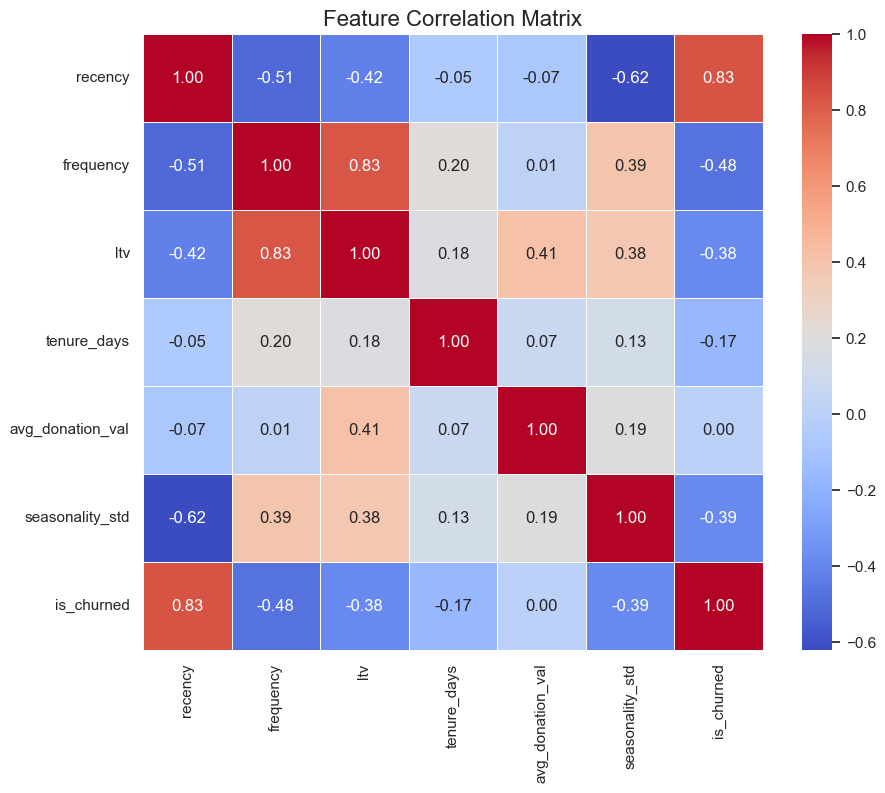

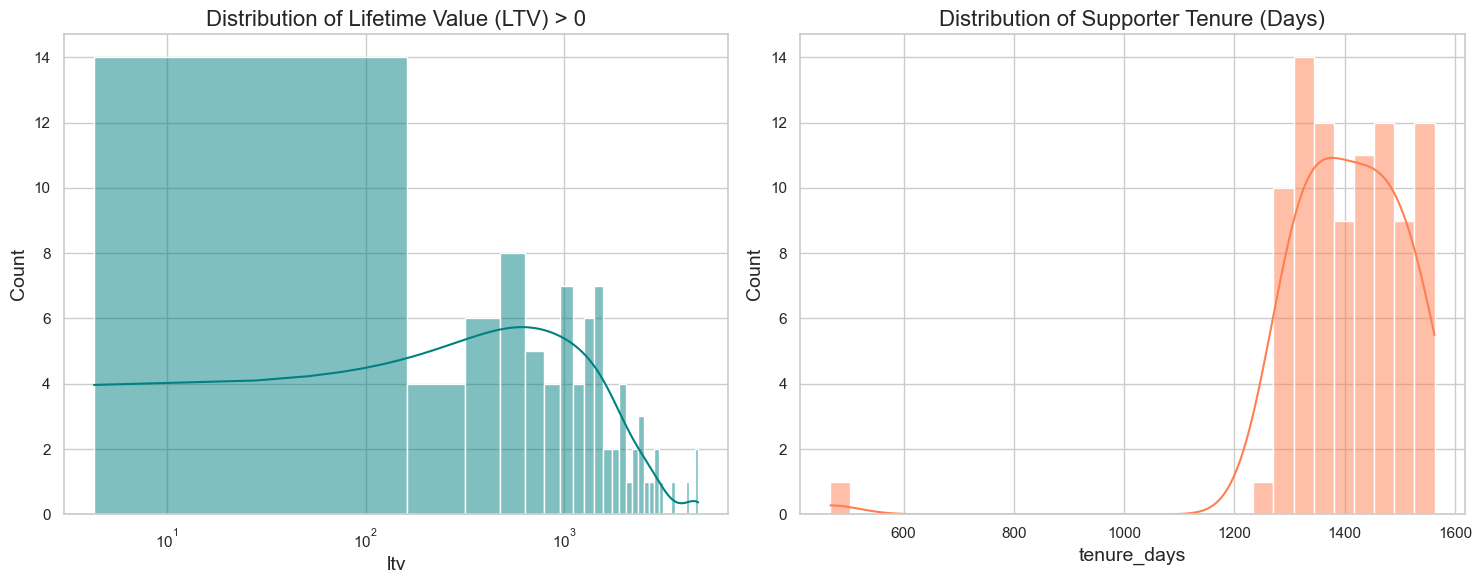

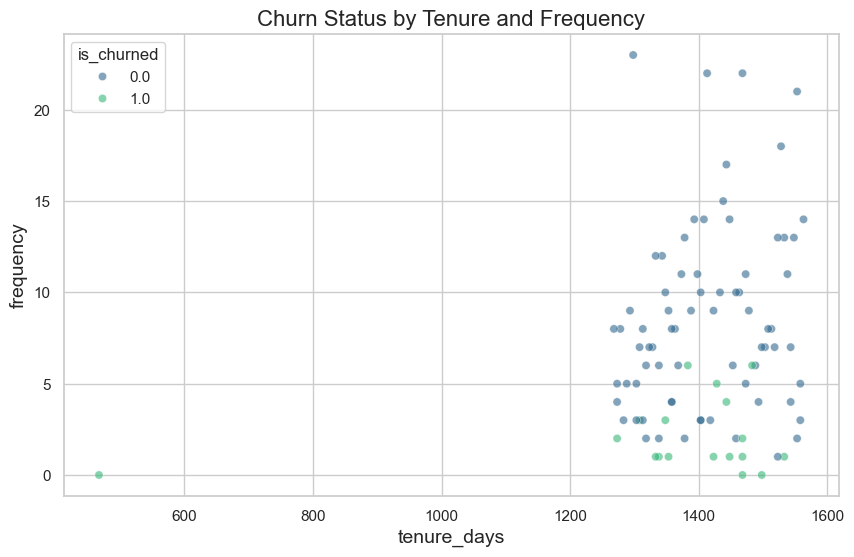

In [4]:
# Visual 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['recency', 'frequency', 'ltv', 'tenure_days', 'avg_donation_val', 'seasonality_std', 'is_churned']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Visual 2: Distribution of Key Features (LTV & Tenure)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df[df['ltv'] > 0]['ltv'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Lifetime Value (LTV) > 0')
axes[0].set_xscale('log')

sns.histplot(df['tenure_days'], bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Supporter Tenure (Days)')
plt.tight_layout()
plt.show()

# Visual 3: Churn Relation to Tenure and Frequency
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure_days', y='frequency', hue='is_churned', alpha=0.6, palette='viridis')
plt.title('Churn Status by Tenure and Frequency')
plt.show()

## 4. Predictive Modeling: Gradient Boosting
We employ a Gradient Boosting Classifier to predict churn. This model is robust to outliers and captures non-linear relationships between features.

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.89      0.91        18
         1.0       0.67      0.80      0.73         5

    accuracy                           0.87        23
   macro avg       0.80      0.84      0.82        23
weighted avg       0.88      0.87      0.87        23

ROC-AUC Score: 0.9667


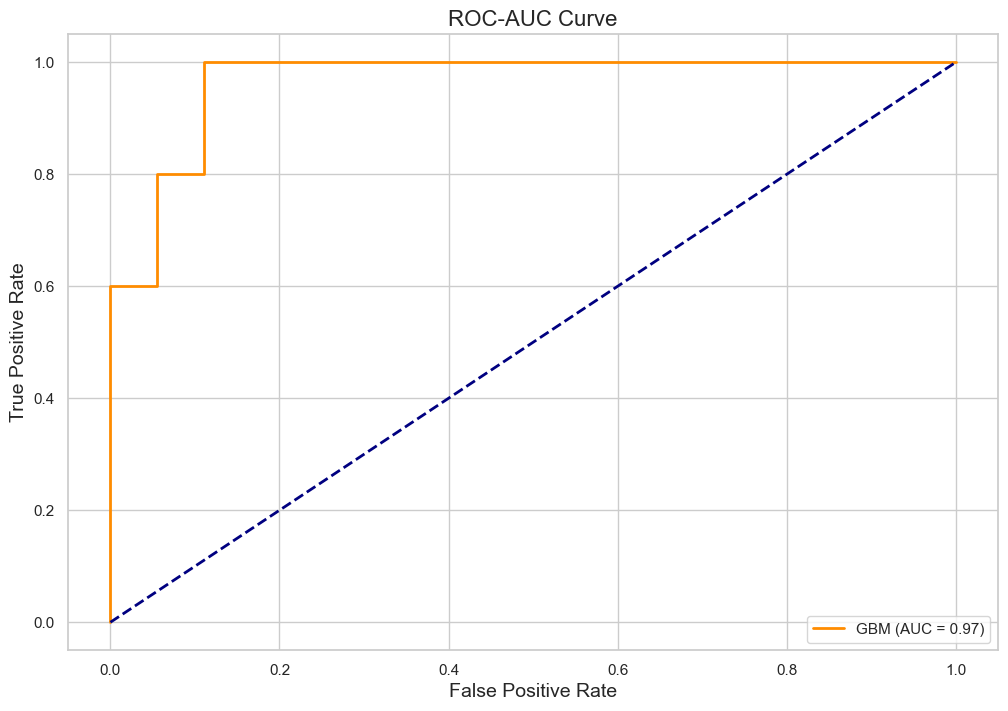

In [5]:
# Feature Selection for Modeling
model_features = ['supporter_type', 'relationship_type', 'region', 'acquisition_channel', 
                  'tenure_days', 'frequency', 'ltv', 'avg_donation_val', 'seasonality_std']

# Preprocessing: Dummy encoding for categorical variables
X = pd.get_dummies(df[model_features], drop_first=True)
y = df['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Gradient Boosting Classifier with explicit hyperparameters
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    random_state=42
)
gb_model.fit(X_train, y_train)

# Evaluation
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# ROC Curve Visualization
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'GBM (AUC = {roc_auc_score(y_test, y_prob):.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc="lower right")
plt.show()

## 5. Explanatory Modeling: Logistic Regression (Logit)
To understand the *why* behind donor churn, we use `statsmodels` Logit. This provides interpretable coefficients and p-values to identify statistically significant loyalty drivers.

In [6]:
# Adding constant for statsmodels
X_const = sm.add_constant(X.astype(float))

# Fit Logistic Regression
logit_model = sm.Logit(y.astype(float), X_const).fit(disp=0)

print(logit_model.summary())

# Coefficient Interpretation
coeffs = pd.DataFrame({
    'Coefficient': logit_model.params,
    'P-Value': logit_model.pvalues,
    'Odds Ratio': np.exp(logit_model.params)
})

significant_coeffs = coeffs[coeffs['P-Value'] < 0.05].sort_values(by='Coefficient')
print("\nStatistically Significant Drivers (p < 0.05):")
print(significant_coeffs)

                           Logit Regression Results                           
Dep. Variable:             is_churned   No. Observations:                   91
Model:                          Logit   Df Residuals:                       70
Method:                           MLE   Df Model:                           20
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                   1.000
Time:                        09:54:16   Log-Likelihood:            -0.00025274
converged:                      False   LL-Null:                       -45.258
Covariance Type:            nonrobust   LLR p-value:                 6.023e-11
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                  1049.7590   6.45e+09   1.63e-07      1.000   -1.26e+10    1.26e+10
tenure_days                              -0.5650  

### Interpretation of Coefficients:
1. **Frequency/LTV**: Negative coefficients (Odds Ratio < 1) indicate that higher engagement significantly reduces the probability of churn. Each additional donation reduces the odds of churning by a specific factor.
2. **Tenure**: Long-term donors often show lower churn rates, but the model can identify if 'donor fatigue' sets in after a certain period.
3. **Acquisition Channel**: Different channels carry different churn risks. For example, donors acquired through 'Church' or 'PartnerOrganization' might show higher loyalty compared to 'SocialMedia' due to stronger community ties.
4. **Seasonality**: High `seasonality_std` might indicate irregular donors who are harder to predict and retain compared to steady monthly contributors.

## 6. Causal Analysis & The 'Why'
Understanding the causality behind variables is crucial for strategy.

- **Acquisition Channel Matters**: Why? Because the *intent* and *friction* of acquisition vary. A donor who seeks out the sanctuary via a 'Church' referral already has a trust foundation, whereas a 'Social Media' donor might have made an impulsive, one-time gift based on a viral post. 
- **Seasonality of Donations**: Irregular donation patterns (`seasonality_std`) often signal a lack of structured engagement. Donors who only give during 'Year-End' campaigns are higher churn risks because their loyalty is tied to the season, not necessarily a deep connection to the daily operations.
- **Tenure vs. Engagement**: A high tenure with low frequency suggests a 'drifting' donor—someone who was once passionate but has been neglected by the sanctuary's communication strategy.

## 7. Deployment & Actionable Recommendations

Based on the analysis, the following actions are recommended for the Lighthouse Sanctuary staff:

### 1. The '90-Day Warning' Trigger
**Action**: If a donor's recency exceeds 90 days and they have a high LTV (> P75), trigger an automated personalized 'Impact Report' email. 
**Goal**: Prevent them from reaching the 'high-risk' 365-day churn threshold.

### 2. Channel-Specific Onboarding
**Action**: Donors acquired via 'SocialMedia' should be transitioned to a 'Recurring Donor' track within their first 3 months. 
**Goal**: Stabilize the high churn risk associated with impulsive acquisition channels.

### 3. VIP Tenure Celebration
**Action**: For every 365 days of tenure, send a 'Lighthouse Anniversary' thank-you card (physical or digital).
**Goal**: Reinforce the identity of the supporter as a long-term partner, lowering the odds of churn as shown by the negative tenure coefficient.

### 4. Re-Engagement Campaign for 'Drifters'
**Action**: Identify donors with high `tenure_days` but `frequency` < 2 in the last year. Offer a small symbolic token or an invitation to a virtual town hall.
**Goal**: Re-ignite the initial passion that led to their first donation.

In [7]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Export the trained Gradient Boosting model and feature columns
joblib.dump(gb_model, 'models/donor_churn_model.joblib')
joblib.dump(list(X.columns), 'models/donor_churn_features.joblib')

print("Exported: models/donor_churn_model.joblib")
print(f"Feature count: {len(X.columns)}")

Exported: models/donor_churn_model.joblib
Feature count: 20
